# Project Preamble: 

Predict Credit Card Fraud
Credit card fraud is one of the leading causes of identify theft around the world. In 2018 alone, over $24 billion was stolen through fraudulent credit card transactions. Financial institutions employ a wide variety of different techniques to prevent fraud, one of the most common being Logistic Regression.

In this project, you are a Data Scientist working for a credit card company. You have access to a dataset (based on a synthetic financial dataset), that represents a typical set of credit card transactions. transactions.csv is the original dataset containing 200k transactions. For starters, we’re going to work with a small portion of this dataset, transactions_modified.csv, which contains 1,000 transactions. Your task is to use Logistic Regression to create a predictive model that determines whether a transaction is fraudulent.

Note that a solution.py file is loaded for you in the workspace, which contains the solution code for this project. We highly recommend that you complete the project on your own without checking the solution, but feel free to take a look if you get stuck or want to check your answers when you’re done!


# Step-1: 


   **Original Response ->** 
     The file transactions_modified.csv contains data on 1000 simulated credit card transactions. Let’s begin by loading the data into a pandas    
     DataFrame named transactions. Take a peek at the dataset using .head(), and you can use .info() to examine how many rows are there and what  
     datatypes they are. How many transactions are fraudulent? Print your answer.




   **Deliverables ->**
  - Load transactions_modified.csv into a DataFrame named transactions
  - Run .head() — what columns do you see?
  - Run .info() — how many rows are there?
  - From .info() — what datatypes are present (ints, floats, objects)?
  - Which column tells you whether a transaction is fraudulent?
  - How many transactions are fraudulent? Print the answer.

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the data
transactions = pd.read_csv('transactions_modified.csv')
print(transactions.head())
print(transactions.info())
# Datatypes Present, Fraud Column Position
print("Combinations of object, ints, and floats")
print("Fraud is 10th Column") 

# How many fraudulent transactions?
print("Total Fraud = ", transactions["isFraud"].sum())

   step      type      amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0   206  CASH_OUT    62927.08   C473782114           0.00            0.00   
1   380   PAYMENT    32851.57  C1915112886           0.00            0.00   
2   570  CASH_OUT  1131750.38  C1396198422     1131750.38            0.00   
3   184  CASH_OUT    60519.74   C982551468       60519.74            0.00   
4   162   CASH_IN    46716.01  C1759889425     7668050.60      7714766.61   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isPayment  \
0  C2096898696       649420.67       712347.75        0          0   
1   M916879292            0.00            0.00        0          1   
2  C1612235515       313070.53      1444820.92        1          0   
3  C1378644910        54295.32       182654.50        1          0   
4  C2059152908      2125468.75      2078752.75        0          0   

   isMovement  accountDiff  
0           1    649420.67  
1           0         0.00  
2           1    818679.85  


# Step-2: 

**Deliverables->**

Looking at the dataset, along with our general knowledge of credit card transactions, we can see a few interesting columns to examine. We know that the amount of a given transaction will be important. Calculate summary statistics for this column. What does the distribution look like?

**Helpful Review**: 

 .describe() is a pandas method that returns summary statistics for numeric columns in one shot. Called on a Series or
  DataFrame:

  transactions['amount'].describe()



count    1.000000e+03
mean     5.373080e+05
std      1.423692e+06
min      0.000000e+00
25%      2.933705e+04
50%      1.265305e+05
75%      3.010378e+05
max      1.000000e+07
Name: amount, dtype: float64


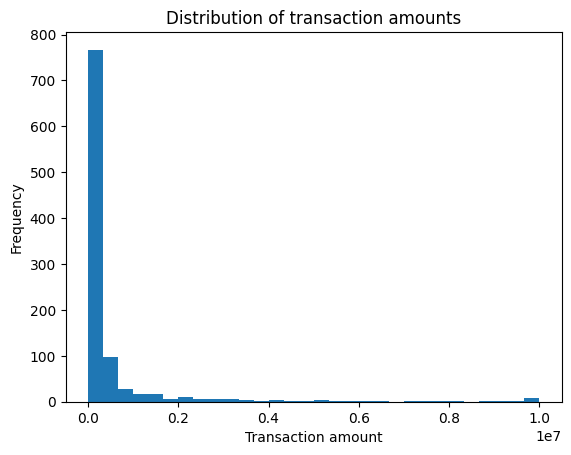

Shape displays Left-skewness


In [2]:
# Summary statistics on the amount column
print(transactions["amount"].describe())

#histogramming the information
plt.hist(transactions['amount'], bins=30)
plt.xlabel('Transaction amount')
plt.ylabel('Frequency')
plt.title('Distribution of transaction amounts')
plt.show()
print("Shape displays Left-skewness")


# Step-3: 

**Deliverables->**


We have a lot of information about the type of transaction we are looking at. Let’s create a new column called isPayment that assigns a 1 when type is “PAYMENT” or “DEBIT”, and a 0 otherwise.

**Review->**

 Here's the idiomatic pandas approach:

  transactions['isPayment'] = transactions['type'].isin(['PAYMENT', 'DEBIT']).astype(int)

  What's happening:
  1. transactions['type'].isin(['PAYMENT', 'DEBIT']) → boolean Series (True/False per row)
  2. .astype(int) → converts True→1, False→0
  3. Assigns the result as a new column

  Why this beats the two-step version:
  - One line, no intermediate state
  - No chained indexing → no SettingWithCopyWarning risk
  - Vectorized — fast on large DataFrames
  - Reads naturally: "isPayment is whether type is in this set"

  Alternative if you prefer explicit ints over astype:
  import numpy as np
  transactions['isPayment'] = np.where(transactions['type'].isin(['PAYMENT', 'DEBIT']), 1, 0)

  Both are fine — .astype(int) is shorter, np.where is handier when the two values aren't 0/1 (e.g., np.where(mask,
  'yes', 'no')).




In [3]:
#making isPayment column and assigning 1/0 values to rows based on Matching 'PAYMENT and/or DEBIT.'
# Create isPayment field
transactions['isPayment'] = transactions['type'].isin(['Payment', 'Debit']).astype(int)

# Step-4: 

**Deliverables->**

Similarly, create a column called isMovement, which will capture if money moved out of the origin account. This column will have a value of 1 when type is either “CASH_OUT” or “TRANSFER”, and a 0 otherwise.

In [4]:
# Create the isMovement field
transactions['isMovement'] = transactions['type'].isin(['CASH_OUT', 'TRANSFER']).astype(int)

# Step-5: 

**Deliverables->**


With financial fraud, another key factor to investigate would be the difference in value between the origin and destination account. Our theory, in this case, being that destination accounts with a significantly different value could be suspect of fraud. Let’s create a column called accountDiff with the absolute difference of the oldbalanceOrg and oldbalanceDest columns.

In [5]:
# Create accountDiff field
transactions['accountDiff'] = abs(transactions['oldbalanceOrg'] - transactions['oldbalanceDest'])

# Step-6: 

**Deliverables->**

Before we can start training our model, we need to define our features and label columns. Our label column in this dataset is the isFraud field. Create a variable called features, which will be an array consisting of the following fields:

- amount
- isPayment
- isMovement
- accountDiff


Also, create a variable called label with the column isFraud.



In [6]:
# Create features and label variables
features =  transactions[["amount", "isPayment", "isMovement", "accountDiff"]]
label =  transactions["isFraud"]

# Step-7: 

**Deliverables->**


Split the data into training and test sets using sklearn‘s train_test_split() method. We’ll use the training set to train the model and the test set to evaluate the model. Use a test_size value of 0.3.


In [7]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(features, label, test_size=0.3) 

# Step-8: 

**Deliverables->**


Since sklearn‘s Logistic Regression implementation uses Regularization, we need to scale our feature data. Create a StandardScaler object, .fit_transform() it on the training features, and .transform() the test features.

In [8]:
# Normalize the feature variables
scalar =   StandardScaler()
X_train =  scalar.fit_transform(X_train) 
X_test = scalar.transform(X_test) 

# Step-9: 

**Deliverables->**

Create a LogisticRegression model with sklearn and .fit() it on the training data.
Fitting the model find the best coefficients for our selected features so it can more accurately predict our label. We will start with the default threshold of 0.5.

In [9]:
# Fit the model to the training data
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


# Step-10-11: 

**Deliverables->**


- Run the model’s .score() method on the training data and print the training score.
Scoring the model on the training data will process the training data through the trained model and will predict which transactions are fraudulent. The score returned is the percentage of correct classifications, or the accuracy.


- Run the model’s .score() method on the test data and print the test score.
Scoring the model on the test data will process the test data through the trained model and will predict which transactions are fraudulent. The score returned is the percentage of correct classifications, or the accuracy, and will be an indicator for the sucess of your model.
How did your model perform?


In [10]:
#Score the model on the training data
print(model.score(X_train, y_train))


# Score the model on the test data
print(model.score(X_test, y_test))

0.8457142857142858
0.84


# Step-12: 

**Deliverables->**

Print the coefficients for our model to see how important each feature column was for prediction. Which feature was most important? Least important?

In [11]:
# Print the model coefficients
print(model.coef_)

[[ 2.44508518  0.          2.36575054 -1.08623789]]


# Step-13: 

**Deliverables->**


Let’s use our model to process more transactions that have gone through our systems. There are three numpy arrays pre-loaded in the workspace with information on new sample transactions under “New transaction data”.

**New transaction data:**
transaction1 = np.array([123456.78, 0.0, 1.0, 54670.1]);
transaction2 = np.array([98765.43, 1.0, 0.0, 8524.75]);
transaction3 = np.array([543678.31, 1.0, 0.0, 510025.5])


Create a fourth array, your_transaction, and add any transaction information you’d like. Make sure to enter all values as floats with a .!


In [12]:
# New transaction data
transaction1 = np.array([123456.78, 0.0, 1.0, 54670.1])
transaction2 = np.array([98765.43, 1.0, 0.0, 8524.75])
transaction3 = np.array([543678.31, 1.0, 0.0, 510025.5])

# Create a new transaction
your_transaction = np.array([6472.54, 1.0, 0.0, 55901.23])



# Step-14: 

**Deliverables->**

Combine the new transactions and your_transaction into a single numpy array called sample_transactions.

In [13]:
# Combine new transactions into a single array
sample_transactions = np.stack((transaction1, transaction2, transaction3, your_transaction))

# Step-15: 

**Deliverables->**

Since our Logistic Regression model was trained on scaled feature data, we must also scale the feature data we are making predictions on. Using the StandardScaler object created earlier, apply its .transform() method to sample_transactions and save the result to sample_transactions.


In [15]:
# Normalize the new transactions
sample_transactions = scalar.transform(sample_transactions)

/home/plewis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# Step-16: 

**Deliverables->**


Which transactions are fraudulent? Use your model’s .predict() method on sample_transactions and print the result to find out.
Want to see the probabilities that led to these predictions? Call your model’s .predict_proba() method on sample_transactions and print the result. The 1st column is the probability of a transaction not being fraudulent, and the 2nd column is the probability of a transaction being fraudulent (which was calculated by our model to make the final classification decision).

In [17]:
# Predict fraud on the new transactions
print(model.predict(sample_transactions))

# Show probabilities on the new transactions
print(model.predict_proba(sample_transactions))

[0 0 0 0]
[[0.59118    0.40882   ]
 [0.99469717 0.00530283]
 [0.98998392 0.01001608]
 [0.99554556 0.00445444]]
